# Bayesian Causal Forest for HTE — stochtree implementation

**Model**: BCF for binary outcomes (probit link) following Hahn, Murray & Carvalho (2020).  
Baseline risk $\mu(X, \hat{\pi})$ and treatment effect surface $\tau(X)$ are modelled with separate BART components using a purpose-built BCF sampler (not NUTS), avoiding the joint non-identifiability problems of a PyMC implementation.

$$Y_i \sim \text{Bernoulli}\left(\Phi\left(\mu(x_i, \hat{\pi}_i) + \tau(x_i) \cdot T_i\right)\right)$$

- $\mu(x_i, \hat{\pi}_i)$ — **prognostic function**: baseline risk on the probit scale, adjusted for targeted selection via the logit propensity score $\hat{\pi}_i$
- $\tau(x_i)$ — **treatment effect function**: CATE on the probit scale; regularised toward zero
- $T_i \in \{0, 1\}$ — treatment indicator
- $\Phi(\cdot)$ — standard normal CDF (probit link)

**Why stochtree instead of PyMC-BART?**

| Issue | PyMC-BART joint model | stochtree BCF |
|---|---|---|
| Sampler | NUTS + PGBART (mismatched) | Purpose-built BCF MCMC |
| Joint identifiability | μ and τ compete; non-identified | Orthogonal updates by design |
| Binary outcome link | `response='constant'` mismatch | Native probit BCF support |
| T in X_tau | Manual exclusion required | Automatically excluded |
| Initialisation | Arbitrary y_latent scaling | Principled zero-centred prior |

## 0. Installation

```bash
pip install stochtree scikit-learn arviz seaborn
```

`stochtree` ships with C++ bindings for the BCF sampler. No R dependency.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from scipy.stats import norm
from scipy.special import expit
from sklearn.tree import DecisionTreeRegressor
import shap
import warnings
warnings.filterwarnings("ignore")

# stochtree: purpose-built BCF sampler
from stochtree import BCFModel, OutcomeModel

rng = np.random.default_rng(123)
output_folder = "ISYE6420/Project/"

## 1. Data Loading and Preparation

In [2]:
cohort = pd.read_csv(f"{output_folder}data/asthma_weighted_cohort.csv")
 
y_data = (cohort["outcome"].values > 0).astype(float)   # binary float 0/1 required
T      = cohort["exposure"].values.astype(float)         # Z_train must be float
 
eps    = 1e-6
pi_hat = np.clip(cohort["ps_score"].values, eps, 1 - eps).astype(float)
 
num_exac_pats = y_data.mean()
print(f"Cohort: {len(cohort):,}  |  Events: {num_exac_pats:.2%}  |  Treated: {T.mean():.2%}")
 
# Feature matrix — NO treatment column, NO propensity column
# stochtree handles both separately via Z_train and propensity_train
drop_cols     = ["patid", "outcome", "exposure", "follow_up_time", "weight", "ps_score"]
X_train       = cohort.drop(columns=drop_cols).astype(float).values
feature_names = cohort.drop(columns=drop_cols).columns.tolist()
 
print(f"X_train: {X_train.shape}  |  Features: {feature_names}")

Cohort: 18,022  |  Events: 4.95%  |  Treated: 75.17%
X_train: (18022, 37)  |  Features: ['age', 'gina_step', 'total_exac_count', 'num_treatments_baseline', 'num_outpatient_event', 'num_er_event', 'hba1c_missing', 'atopic_disease_flag', 'ckd_flag', 'dyslipidemia_flag', 'eosinophilic_disease_flag', 'heart_failure_flag', 'hypertension_flag', 'ischemic_stroke_flag', 'nasal_polyps_flag', 'obstructive_sleep_apnea_flag', 't2dm_flag', 'bmi_20_25', 'bmi_above_25', 'bmi_present', 'Acute_IHD_flag', 'CAD_flag', 'PVD_flag', 'Biologics_flag', 'ICS_flag', 'ICS_LABA_flag', 'ICS_LABA_LAMA_flag', 'LTRA_flag', 'OCS_flag', 'SABA_flag', 'SABA_SAMA_flag', 'sex_Female', 'region_Midwest', 'region_Northeast', 'region_South', 'region_Southwest', 'region_West']


## 2. Feature Matrices

**Key design decisions vs the original PyMC notebook:**

1. `X_mu` includes logit propensity score — the BCF identification argument requires this to absorb targeted selection bias into the prognostic surface.
2. `X_tau` does **not** include `T` or the propensity score. The treatment indicator is passed separately to `BCFModel.sample()`; stochtree handles the $\tau(x) \cdot T$ product internally. Including T in X_tau would allow tau to split on treatment assignment, breaking causal identification.
3. Both matrices exclude `patid`, `outcome`, `exposure`, `follow_up_time`, `weight`, and `ps_score` from the raw cohort.

In [3]:
# Base covariate matrix (no outcome, no treatment, no admin cols)
drop_cols = ["patid", "outcome", "exposure", "follow_up_time", "weight", "ps_score"]
X_base = cohort.drop(columns=drop_cols).astype(int)

# Logit-transform propensity scores for mu (stabilises the probit scale)
eps = 1e-6
ps_values = np.clip(cohort["ps_score"], eps, 1 - eps)
logit_ps  = np.log(ps_values / (1 - ps_values))

# --- Prognostic feature matrix: covariates + logit PS ---
X_mu = X_base.copy()
X_mu["logit_ps"] = logit_ps
X_mu = X_mu.values.astype(float)

# --- Treatment effect feature matrix: covariates ONLY (no T, no PS) ---
# T is passed separately; PS is a confounder for baseline risk, not HTE
X_tau = X_base.values.astype(float)

print(f"X_mu shape : {X_mu.shape}")
print(f"X_tau shape: {X_tau.shape}")
print(f"Covariate columns: {list(X_base.columns)}")

X_mu shape : (18022, 38)
X_tau shape: (18022, 37)
Covariate columns: ['age', 'gina_step', 'total_exac_count', 'num_treatments_baseline', 'num_outpatient_event', 'num_er_event', 'hba1c_missing', 'atopic_disease_flag', 'ckd_flag', 'dyslipidemia_flag', 'eosinophilic_disease_flag', 'heart_failure_flag', 'hypertension_flag', 'ischemic_stroke_flag', 'nasal_polyps_flag', 'obstructive_sleep_apnea_flag', 't2dm_flag', 'bmi_20_25', 'bmi_above_25', 'bmi_present', 'Acute_IHD_flag', 'CAD_flag', 'PVD_flag', 'Biologics_flag', 'ICS_flag', 'ICS_LABA_flag', 'ICS_LABA_LAMA_flag', 'LTRA_flag', 'OCS_flag', 'SABA_flag', 'SABA_SAMA_flag', 'sex_Female', 'region_Midwest', 'region_Northeast', 'region_South', 'region_Southwest', 'region_West']


## 3. BCF Model — stochtree

### Prior configuration

stochtree's BCF follows the Hahn et al. (2020) defaults. The key parameters:

| Parameter | μ (prognostic) | τ (treatment effect) | Rationale |
|---|---|---|---|
| `num_trees` | 200 | 50 | More trees → shallower on average; tau is more regularised |
| `alpha` (depth prior) | 0.95 | 0.25 | Hahn defaults; tau strongly shrunk toward homogeneity |
| `beta` (depth prior) | 2 | 3 | tau gets additional depth penalty |

**Why these differ from the original notebook's mu prior (alpha=0.90):**  
alpha=0.95 with 200 trees keeps individual trees shallow (high alpha is offset by splitting the signal across more trees), whereas alpha=0.90 with 100 trees produces fewer but deeper trees that overfit the 5.5% prevalence baseline and starve tau of signal.

### Outcome scale

stochtree's BCF with `outcome_model='probit'` handles the binary outcome natively. It internally augments the data with latent Gaussian draws (Albert & Chib data augmentation) — you do **not** need to manually construct `y_latent`. This is the correct approach for binary BCF; passing raw ±1 encodings as PyMC-BART's `Y` argument was a misspecification.

In [ ]:
general_params = {
    "outcome_model"       : OutcomeModel(outcome="binary", link="probit"),
    "propensity_covariate": "prognostic",   # PS enters mu forest only, never tau
    "adaptive_coding"     : True,
    "random_seed"         : 123,
    "keep_every"          : 5,
    "num_chains"          : 4,
    "standardize"         : True,
}

# Hahn defaults: alpha=0.95, beta=2; 250 trees keeps individuals shallow
prognostic_forest_params = {
    "num_trees"       : 200,
    "alpha"           : 0.95,
    "beta"            : 2.0,
    "min_samples_leaf": 20,
    "max_depth"       : 10,
}

# Strong regularisation toward homogeneous CATE: alpha=0.25, beta=3
# delta_max: max plausible risk difference; conservative for ~5.5% prevalence
treatment_effect_forest_params = {
    "num_trees"       : 100,
    "alpha"           : 0.25,
    "beta"            : 3.0,
    "min_samples_leaf": 20,
    "max_depth"       : 8,
    "delta_max"       : 0.2,
    "sample_intercept": True,
    "sample_sigma2_leaf": True,
}

bcf = BCFModel()   # no args here
 
bcf.sample(
    X_train                        = X_train,
    Z_train                        = T,
    y_train                        = y_data,
    propensity_train               = pi_hat,
    num_gfr                        = 20,    # warm-start; must be >= num_chains
    num_burnin                     = 0,
    num_mcmc                       = 1000,   # retained draws per chain
    general_params                 = general_params,
    prognostic_forest_params       = prognostic_forest_params,
    treatment_effect_forest_params = treatment_effect_forest_params,
)

print("Sampling complete.")
bcf.summary()


Sampling complete.
BCF Model Summary:
------------------
BCFModel run with prognostic forest, treatment effect forest, prognostic forest leaf scale model, treatment effect forest leaf scale model, and treatment effect intercept model
Outcome was modeled as gaussian
Treatment was binary and its effect was estimated with adaptive coding
Outcome was standardized
User-provided propensity scores were included in the model
The sampler was run for 20 GFR iterations, with 4 chains of 0 burn-in iterations and 1000 MCMC iterations, retaining every 5th iteration (i.e. thinning)

Summary of prognostic forest leaf scale posterior: 4000 samples, mean = 0.001, standard deviation = 0.001, quantiles:
    2.5%: 0.001
   10.0%: 0.001
   25.0%: 0.001
   50.0%: 0.001
   75.0%: 0.002
   90.0%: 0.002
   97.5%: 0.003
Summary of treatment effect forest leaf scale posterior: 4000 samples, mean = 0.004, standard deviation = 0.002, quantiles:
    2.5%: 0.001
   10.0%: 0.001
   25.0%: 0.002
   50.0%: 0.003
   75.0

## 4. Extract Posterior Draws

stochtree returns:
- `mu_hat_train`  — posterior draws of $\mu(x_i, \hat{\pi}_i)$, shape `(N, num_mcmc)`
- `tau_hat_train` — posterior draws of $\tau(x_i)$, shape `(N, num_mcmc)`
- `y_hat_train`   — posterior draws of $\Phi(\mu + \tau T)$, shape `(N, num_mcmc)`

Note the transposed convention vs ArviZ (`(N, draws)` not `(chains, draws, N)`); we reshape as needed.

In [5]:
# Each call returns a plain np.array of shape (N, total_draws)
eps_prob  = 1e-6
mu_prob   = bcf.predict(X=X_train, Z=T, propensity=pi_hat,
                        terms="prognostic_function", scale="linear")
tau_prob  = bcf.predict(X=X_train, Z=T, propensity=pi_hat,
                        terms="cate", scale="linear")
mu_draws  = norm.ppf(np.clip(mu_prob,  eps_prob, 1 - eps_prob))
tau_draws = norm.ppf(np.clip(tau_prob, eps_prob, 1 - eps_prob))

yhat_prob  = bcf.predict(X=X_train, Z=T, propensity=pi_hat,
                         terms="y_hat", scale="linear")

# Verify shapes
assert mu_draws.ndim == 2,  f"Expected 2D, got {mu_draws.shape}"
assert tau_draws.ndim == 2, f"Expected 2D, got {tau_draws.shape}"
print(f"mu_draws  : {mu_draws.shape}  — (N, total_draws)")
print(f"tau_draws : {tau_draws.shape}")
print(f"yhat_prob : {yhat_prob.shape}")

# Posterior summaries
tau_mean  = tau_draws.mean(axis=1)
tau_sd    = tau_draws.std(axis=1)
tau_lo95  = np.percentile(tau_draws, 2.5,  axis=1)
tau_hi95  = np.percentile(tau_draws, 97.5, axis=1)
tau_lo50  = np.percentile(tau_draws, 25,   axis=1)
tau_hi50  = np.percentile(tau_draws, 75,   axis=1)
mu_mean   = mu_draws.mean(axis=1)
yhat_mean = yhat_prob.mean(axis=1)

treated_idx = np.where(T == 1)[0]
control_idx = np.where(T == 0)[0]
n_draws     = tau_draws.shape[1]

print(f"\nTotal draws          : {n_draws}  (4 chains × 500)")
print(f"ATE (latent probit)  : {tau_mean.mean():.4f}  SD={tau_mean.std():.4f}")
print(f"ATT (latent probit)  : {tau_mean[treated_idx].mean():.4f}")

# Risk difference: compute_contrast with scale="probability"
# Returns plain np.array (N, total_draws)
T1 = np.ones(len(y_data))
T0 = np.zeros(len(y_data))
rd_draws = bcf.compute_contrast(
    X_0=X_train, Z_0=T0, propensity_0=pi_hat,
    X_1=X_train, Z_1=T1, propensity_1=pi_hat,
    type="posterior", scale="probability",
)

ird_mean = rd_draws.mean(axis=1)
ird_lo95 = np.percentile(rd_draws, 2.5,  axis=1)
ird_hi95 = np.percentile(rd_draws, 97.5, axis=1)

# Native 95% CI for tau
ci_tau    = bcf.compute_posterior_interval(
    X=X_train, Z=T, propensity=pi_hat,
    terms="cate", level=0.95, scale="linear"
)   # returns dict {"lower": (N,), "upper": (N,)}
tau_ci_lo = ci_tau["lower"]
tau_ci_hi = ci_tau["upper"]



mu_draws  : (18022, 4000)  — (N, total_draws)
tau_draws : (18022, 4000)
yhat_prob : (18022, 4000)

Total draws          : 4000  (4 chains × 500)
ATE (latent probit)  : -3.3834  SD=0.7989
ATT (latent probit)  : -3.3784


## 5. Convergence Diagnostics

stochtree runs a single chain by design (the BCF sampler is not easily parallelised in the same way as NUTS). We assess convergence via:
- Trace plots of aggregate posterior quantities (ATE per draw)
- Effective sample size on the marginal ATE posterior
- Autocorrelation of tau draws

R̂ is not computable from a single chain; if you need multi-chain diagnostics, run `BCFModel.sample()` with different `random_seed` values and compare marginal ATE distributions.


ATE R̂   : 1.1698  (target < 1.01)
ATE ESS : 18 / 4000 total draws
⚠  R̂ > 1.01 — consider increasing num_gfr or num_mcmc


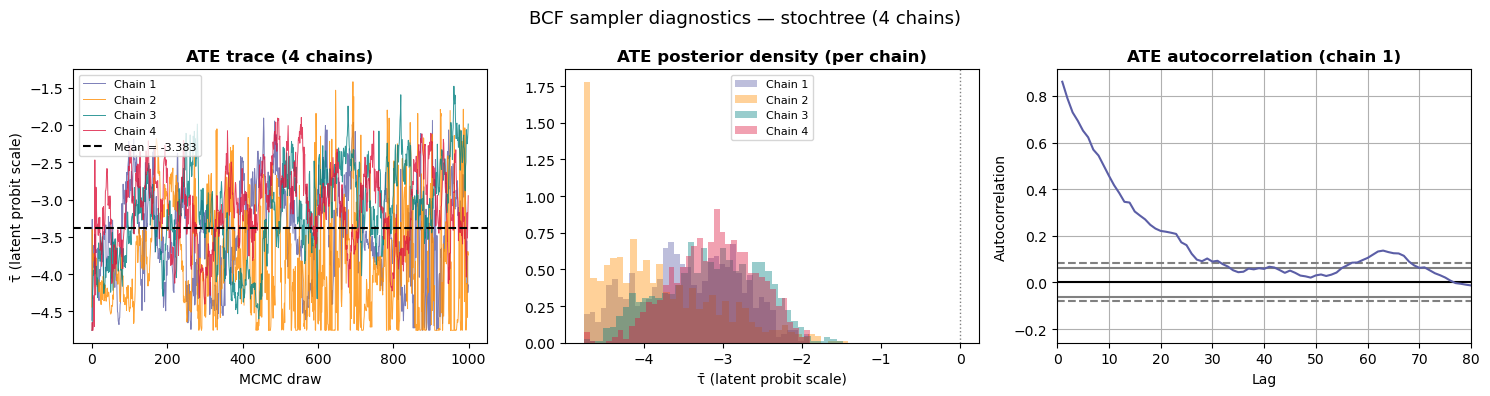

In [6]:
NUM_CHAINS = 4
NUM_MCMC   = 1000

ate_trace_flat = tau_draws.mean(axis=0)                          # (total_draws,)
ate_chains     = ate_trace_flat.reshape(NUM_CHAINS, NUM_MCMC)    # (chains, draws)

rhat_val = az.rhat(ate_chains)
ess_val  = az.ess(ate_chains)
print(f"\nATE R̂   : {float(rhat_val):.4f}  (target < 1.01)")
print(f"ATE ESS : {float(ess_val):.0f} / {NUM_CHAINS * NUM_MCMC} total draws")
if float(rhat_val) > 1.01:
    print("⚠  R̂ > 1.01 — consider increasing num_gfr or num_mcmc")
else:
    print("✓  Chains well-mixed")

chain_colours = ["#5B5EA6", "darkorange", "teal", "crimson"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for c in range(NUM_CHAINS):
    axes[0].plot(ate_chains[c], lw=0.7, alpha=0.8,
                 color=chain_colours[c], label=f"Chain {c+1}")
axes[0].axhline(ate_trace_flat.mean(), color="black", lw=1.5, ls="--",
                label=f"Mean = {ate_trace_flat.mean():.3f}")
axes[0].set_title("ATE trace (4 chains)", fontweight="bold")
axes[0].set_xlabel("MCMC draw"); axes[0].set_ylabel("τ̄ (latent probit scale)")
axes[0].legend(fontsize=8)

for c in range(NUM_CHAINS):
    axes[1].hist(ate_chains[c], bins=40, alpha=0.4, density=True,
                 color=chain_colours[c], label=f"Chain {c+1}")
axes[1].axvline(0, color="gray", lw=1, ls=":")
axes[1].set_xlabel("τ̄ (latent probit scale)")
axes[1].set_title("ATE posterior density (per chain)", fontweight="bold")
axes[1].legend(fontsize=8)

from pandas.plotting import autocorrelation_plot
autocorrelation_plot(pd.Series(ate_chains[0]), ax=axes[2], color="#5B5EA6")
axes[2].set_xlim(0, 80)
axes[2].set_title("ATE autocorrelation (chain 1)", fontweight="bold")

fig.suptitle("BCF sampler diagnostics — stochtree (4 chains)", fontsize=13)
fig.tight_layout(); plt.show()

## 6. Posterior Predictive Check

`yhat_draws` gives posterior draws of $\hat{P}(Y_i=1)$ on the probability scale. We compare the distribution of predicted probabilities against the observed event rate and simulate binary outcomes to check calibration.

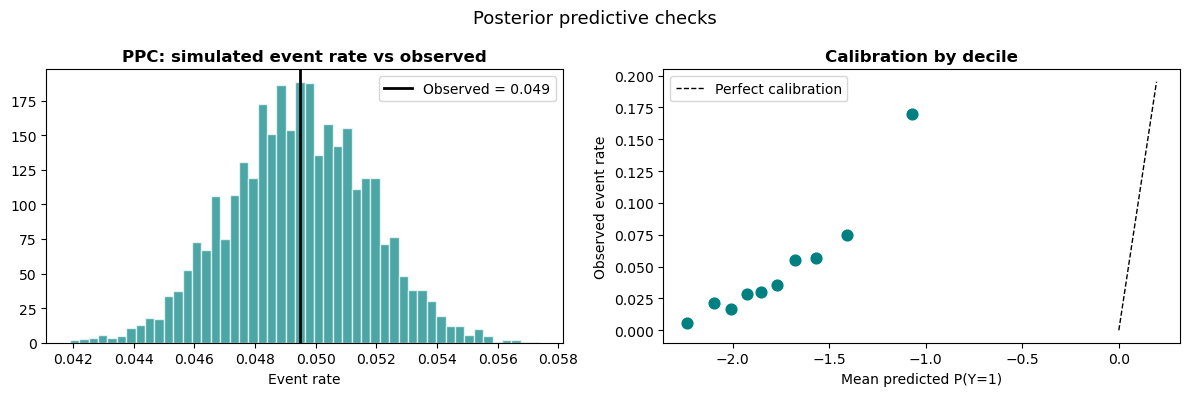

Observed rate : 0.0495
PPC mean      : 0.0494  [0.0450, 0.0538]


In [7]:
ppc_draws       = bcf.sample_posterior_predictive(X=X_train, Z=T, propensity=pi_hat)
ppc_event_rates = ppc_draws.mean(axis=0)
obs_rate        = y_data.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ppc_event_rates, bins=50, color="teal", alpha=0.7, density=True, edgecolor="white")
axes[0].axvline(obs_rate, color="black", lw=2, label=f"Observed = {obs_rate:.3f}")
axes[0].set_xlabel("Event rate")
axes[0].set_title("PPC: simulated event rate vs observed", fontweight="bold")
axes[0].legend()

df_cal = pd.DataFrame({"pred": yhat_mean, "obs": y_data.astype(int)})
df_cal["decile"] = pd.qcut(df_cal["pred"], 10, labels=False, duplicates="drop")
cal_s = (df_cal.groupby("decile")
               .agg(pred_mean=("pred","mean"), obs_mean=("obs","mean"))
               .reset_index())
lims = [0, max(cal_s["pred_mean"].max(), cal_s["obs_mean"].max()) * 1.15]
axes[1].scatter(cal_s["pred_mean"], cal_s["obs_mean"], color="teal", s=60, zorder=3)
axes[1].plot(lims, lims, "k--", lw=1, label="Perfect calibration")
axes[1].set_xlabel("Mean predicted P(Y=1)")   # now correctly on probability scale
axes[1].set_ylabel("Observed event rate")
axes[1].set_title("Calibration by decile", fontweight="bold")
axes[1].legend()

fig.suptitle("Posterior predictive checks", fontsize=13)
fig.tight_layout(); plt.show()

print(f"Observed rate : {obs_rate:.4f}")
print(f"PPC mean      : {ppc_event_rates.mean():.4f}  "
      f"[{np.percentile(ppc_event_rates,2.5):.4f}, {np.percentile(ppc_event_rates,97.5):.4f}]")


Estimand                                Mean                95% CI
-----------------------------------------------------------------
ATE (latent probit)                  -3.3834  [-4.7510, -2.1658]
ATT (latent probit)                  -3.3784  [-4.7516, -2.1407]
ATE (risk difference)                -0.0058  [-0.0135, 0.0008]
ATT (risk difference)                -0.0058  [-0.0138, 0.0009]


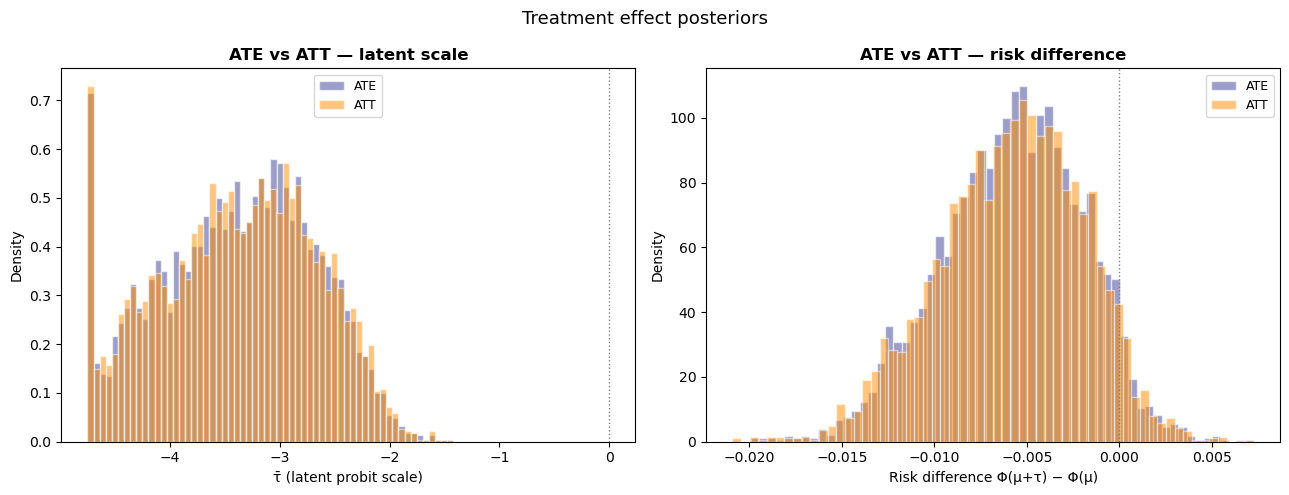

In [8]:
def summarise(trace, level=0.95):
    lo = np.percentile(trace, (1-level)/2*100)
    hi = np.percentile(trace, (1+level)/2*100)
    return trace.mean(), lo, hi

ate_trace = tau_draws.mean(axis=0)
att_trace = tau_draws[treated_idx].mean(axis=0)
ate_rd_tr = rd_draws.mean(axis=0)
att_rd_tr = rd_draws[treated_idx].mean(axis=0)

print("\n" + "="*65)
print(f"{'Estimand':<35} {'Mean':>8}  {'95% CI':>20}")
print("-"*65)
for label, tr in [
    ("ATE (latent probit)", ate_trace),
    ("ATT (latent probit)", att_trace),
    ("ATE (risk difference)", ate_rd_tr),
    ("ATT (risk difference)", att_rd_tr),
]:
    m, lo, hi = summarise(tr)
    print(f"{label:<35} {m:>8.4f}  [{lo:.4f}, {hi:.4f}]")
print("="*65)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ate_t, att_t, xlabel, title in [
    (axes[0], ate_trace, att_trace,
     "τ̄ (latent probit scale)", "ATE vs ATT — latent scale"),
    (axes[1], ate_rd_tr, att_rd_tr,
     "Risk difference Φ(μ+τ) − Φ(μ)", "ATE vs ATT — risk difference"),
]:
    ax.hist(ate_t, bins=60, alpha=0.6, density=True,
            color="#5B5EA6", label="ATE", edgecolor="white")
    ax.hist(att_t, bins=60, alpha=0.5, density=True,
            color="darkorange", label="ATT", edgecolor="white")
    ax.axvline(0, color="gray", lw=1, ls=":")
    ax.set_xlabel(xlabel); ax.set_ylabel("Density")
    ax.set_title(title, fontweight="bold"); ax.legend(fontsize=9)
fig.suptitle("Treatment effect posteriors", fontsize=13)
fig.tight_layout(); plt.show()

## 9. CATT Waterfall Plot

Sorted individual-level treatment effects on the absolute risk difference scale. Green = treatment reduces exacerbation risk (RD < 0), Red = treatment increases or has no benefit (RD > 0).

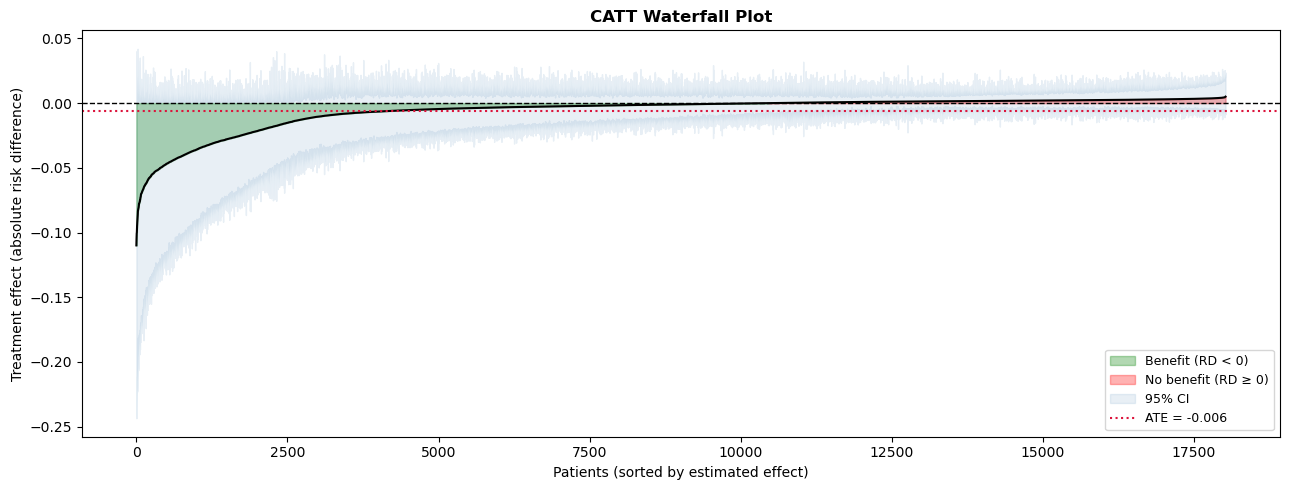

Proportion with estimated benefit (RD < 0): 58.0%


In [9]:
sort_idx = np.argsort(ird_mean)
ird_s    = ird_mean[sort_idx]
ird_lo_s = ird_lo95[sort_idx]
ird_hi_s = ird_hi95[sort_idx]
xs       = np.arange(len(ird_s))

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(xs, 0, ird_s, where=(ird_s < 0),  color="green", alpha=0.3,
                label="Benefit (RD < 0)")
ax.fill_between(xs, 0, ird_s, where=(ird_s >= 0), color="red",   alpha=0.3,
                label="No benefit (RD ≥ 0)")
ax.plot(xs, ird_s, color="black", lw=1.5)
ax.fill_between(xs, ird_lo_s, ird_hi_s, alpha=0.12, color="steelblue", label="95% CI")
ax.axhline(0, color="black", ls="--", lw=1)
ax.axhline(ird_mean.mean(), color="crimson", ls=":", lw=1.5,
           label=f"ATE = {ird_mean.mean():.3f}")
ax.set_ylabel("Treatment effect (absolute risk difference)")
ax.set_xlabel("Patients (sorted by estimated effect)")
ax.set_title("CATT Waterfall Plot", fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

print(f"Proportion with estimated benefit (RD < 0): {(ird_mean < 0).mean():.1%}")

## 10. Credible-Interval Caterpillar Plot (sorted by τ)

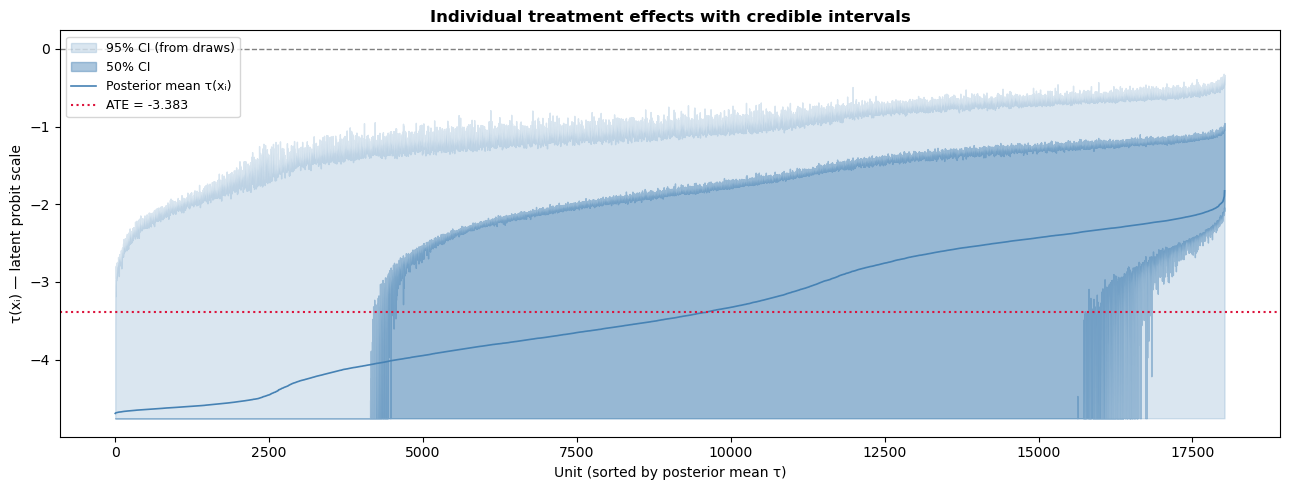

In [10]:
sort_idx_tau = np.argsort(tau_mean)
xs           = np.arange(len(tau_mean))

tau_ci_lo = np.percentile(tau_draws, 2.5,  axis=1)   # (N,)
tau_ci_hi = np.percentile(tau_draws, 97.5, axis=1)   # (N,)
tau_lo50  = np.percentile(tau_draws, 25,   axis=1)
tau_hi50  = np.percentile(tau_draws, 75,   axis=1)

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(xs, tau_ci_lo[sort_idx_tau], tau_ci_hi[sort_idx_tau],
                alpha=0.2, color="steelblue", label="95% CI (from draws)")
ax.fill_between(xs, tau_lo50[sort_idx_tau], tau_hi50[sort_idx_tau],
                alpha=0.45, color="steelblue", label="50% CI")
ax.plot(xs, tau_mean[sort_idx_tau], lw=1.2, color="steelblue",
        label="Posterior mean τ(xᵢ)")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.axhline(tau_mean.mean(), color="crimson", lw=1.5, ls=":",
           label=f"ATE = {tau_mean.mean():.3f}")
ax.set_xlabel("Unit (sorted by posterior mean τ)")
ax.set_ylabel("τ(xᵢ) — latent probit scale")
ax.set_title("Individual treatment effects with credible intervals", fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 11. Treatment Effect vs Prognostic Score

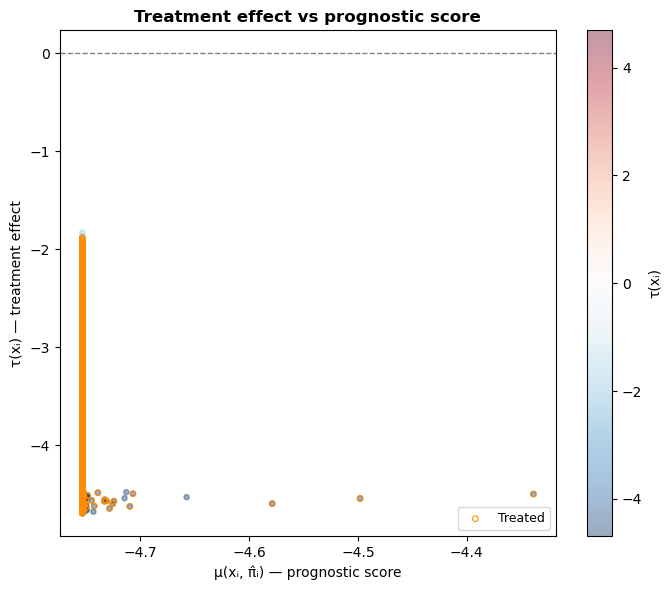

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
vmax = np.abs(tau_mean).max()
sc = ax.scatter(mu_mean, tau_mean, c=tau_mean, cmap="RdBu_r",
                alpha=0.4, s=14, vmin=-vmax, vmax=vmax)
plt.colorbar(sc, ax=ax, label="τ(xᵢ)")
ax.scatter(mu_mean[treated_idx], tau_mean[treated_idx],
           s=16, edgecolors="darkorange", facecolors="none", lw=0.8,
           label="Treated", zorder=5)
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("μ(xᵢ, π̂ᵢ) — prognostic score")
ax.set_ylabel("τ(xᵢ) — treatment effect")
ax.set_title("Treatment effect vs prognostic score", fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()


## 12. HTE Calibration — Do predicted effect groups show the right observed rates?

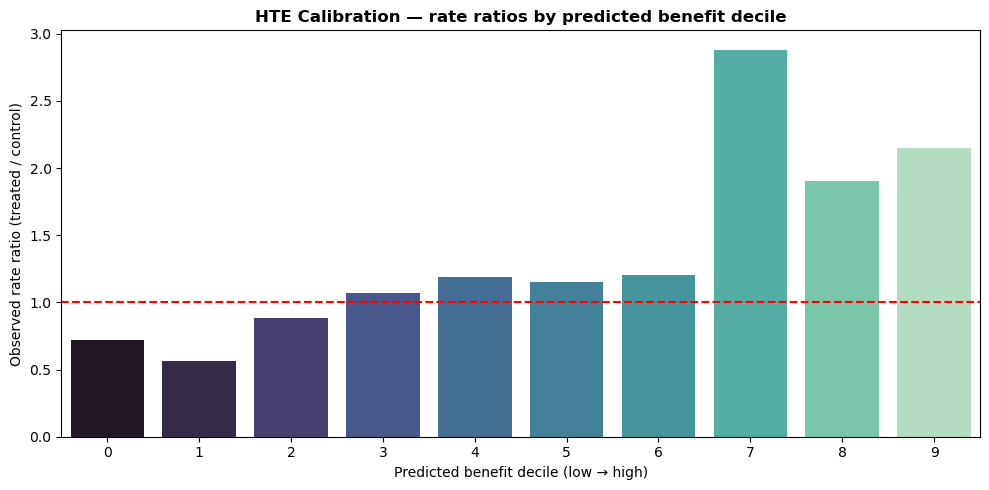

In [12]:
df_eval = pd.DataFrame({
    "pred_rd": ird_mean, "obs_y": y_data.astype(int), "T": T.astype(int)
})
df_eval["decile"] = pd.qcut(df_eval["pred_rd"], 10, labels=False, duplicates="drop")

def safe_rr(x):
    r_t = x[x["T"]==1]["obs_y"].mean()
    r_c = x[x["T"]==0]["obs_y"].mean()
    return r_t / r_c if (r_c > 0 and not np.isnan(r_t)) else np.nan

decile_rr = df_eval.groupby("decile").apply(safe_rr).reset_index()
decile_rr.columns = ["decile", "rate_ratio"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=decile_rr, x="decile", y="rate_ratio", palette="mako", ax=ax)
ax.axhline(1, color="red", ls="--", lw=1.5)
ax.set_xlabel("Predicted benefit decile (low → high)")
ax.set_ylabel("Observed rate ratio (treated / control)")
ax.set_title("HTE Calibration — rate ratios by predicted benefit decile", fontweight="bold")
fig.tight_layout(); plt.show()


## 13. Subgroup CATTs — Forest Plot

For each binary indicator in `feature_list`, we extract the subgroup CATT posterior (mean tau across draws for that subgroup) and plot the 50% and 94% HDI.

                               mean   lo94   hi94  p_benefit      n
feature                                                            
ICS_flag                     -3.808 -4.751 -2.386        1.0    713
ICS_LABA_flag                -3.763 -4.748 -2.349        1.0   3121
ICS_LABA_LAMA_flag           -3.960 -4.751 -2.623        1.0    693
num_treatments_baseline      -2.631 -4.746 -1.089        1.0   4183
hba1c_missing                -3.401 -4.747 -2.189        1.0  13112
dyslipidemia_flag            -3.397 -4.748 -2.193        1.0  13480
PVD_flag                     -3.433 -4.751 -2.181        1.0   2466
CAD_flag                     -3.303 -4.749 -1.932        1.0   3135
t2dm_flag                    -3.399 -4.748 -2.164        1.0  12519
obstructive_sleep_apnea_flag -3.453 -4.748 -2.191        1.0   6278
hypertension_flag            -3.389 -4.746 -2.178        1.0  13629
ckd_flag                     -3.508 -4.752 -2.180        1.0   3132
bmi_20_25                    -3.116 -4.753 -1.52

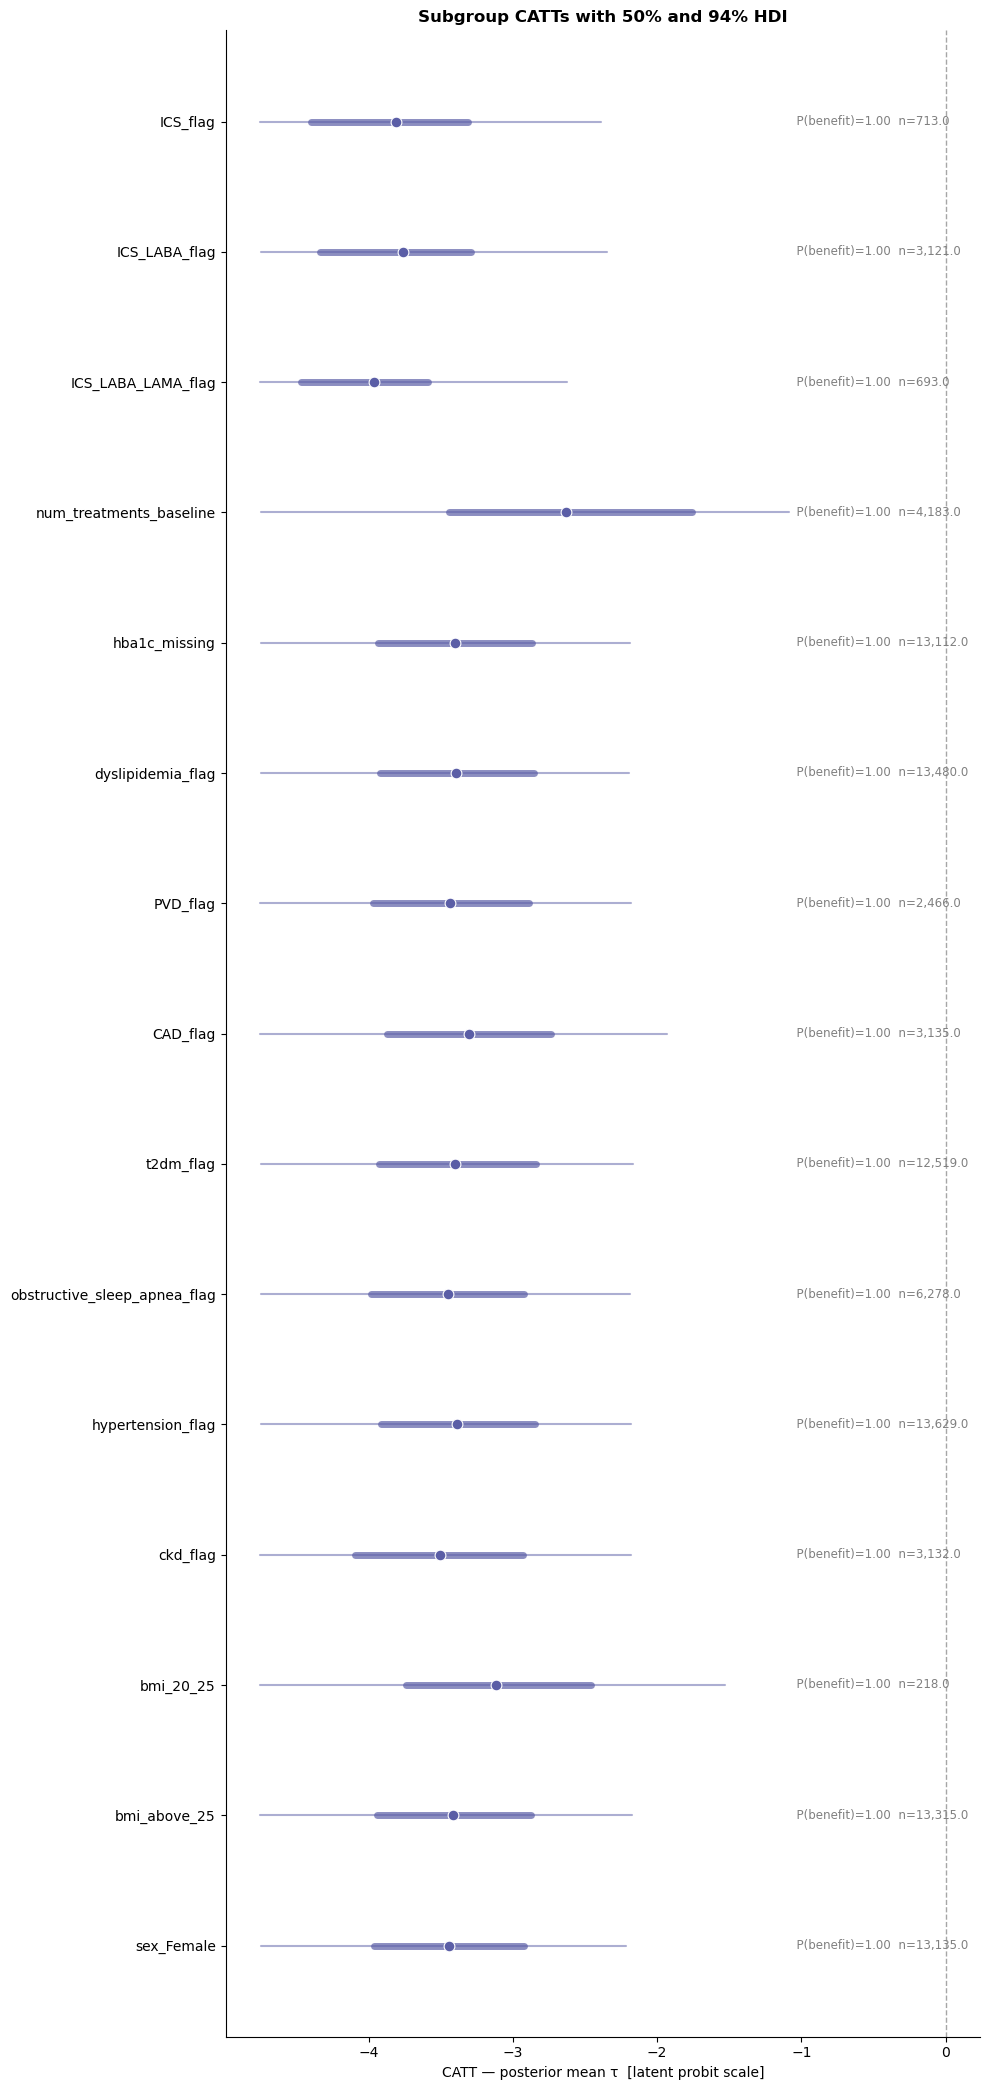

In [13]:
X_df = pd.DataFrame(X_train, columns=feature_names) if not isinstance(X_train, pd.DataFrame) \
       else X_train.copy()

def cate_summary(tau_draws, idx, level=0.94):
    draws = tau_draws[idx].mean(axis=0)
    lo    = np.percentile(draws, (1-level)/2*100)
    hi    = np.percentile(draws, (1+level)/2*100)
    return draws.mean(), lo, hi, np.percentile(draws,25), np.percentile(draws,75), \
           (draws < 0).mean(), len(idx)

feature_list = [
    "ICS_flag", "ICS_LABA_flag", "ICS_LABA_LAMA_flag",
    "num_treatments_baseline", "hba1c_missing", "dyslipidemia_flag",
    "PVD_flag", "CAD_flag", "t2dm_flag",
    "obstructive_sleep_apnea_flag", "hypertension_flag", "ckd_flag",
    "bmi_20_25", "bmi_above_25", "sex_Female",
]

rows = []
for feat in feature_list:
    if feat not in X_df.columns:
        continue
    idx = np.where(X_df[feat].values == 1)[0]
    if len(idx) < 10:
        continue
    m, lo, hi, lo50, hi50, p_b, n = cate_summary(tau_draws, idx)
    rows.append(dict(feature=feat, mean=m, lo94=lo, hi94=hi,
                     lo50=lo50, hi50=hi50, p_benefit=p_b, n=n))

df_forest = pd.DataFrame(rows).set_index("feature")
print(df_forest[["mean","lo94","hi94","p_benefit","n"]].round(3).to_string())

color = "#5B5EA6"
y_pos = np.arange(len(df_forest))[::-1]

fig, ax = plt.subplots(figsize=(10, 1.3*len(df_forest) + 1.5))
for i, (feat, row) in enumerate(df_forest.iterrows()):
    y = y_pos[i]
    ax.plot([row.lo94, row.hi94], [y,y], lw=1.5, color=color,
            alpha=0.5, solid_capstyle="round")
    ax.plot([row.lo50, row.hi50], [y,y], lw=5, color=color,
            alpha=0.7, solid_capstyle="round")
    ax.scatter(row["mean"], y, s=60, color=color, zorder=5,
               edgecolors="white", lw=0.8)
    ax.text(df_forest["hi94"].max() + 0.005, y,
            f"  P(benefit)={row.p_benefit:.2f}  n={row.n:,}",
            va="center", fontsize=8.5, color="gray")

ax.axvline(0, color="gray", lw=1, ls="--", alpha=0.7)
ax.set_yticks(y_pos); ax.set_yticklabels(df_forest.index, fontsize=10)
ax.set_xlabel("CATT — posterior mean τ  [latent probit scale]", fontsize=10)
ax.set_title("Subgroup CATTs with 50% and 94% HDI", fontsize=12, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout(); plt.show()


## 14. Decision Tree Proxy — Clinically Interpretable Rules

A shallow decision tree fitted to the posterior mean ITEs identifies which covariates best explain the heterogeneity surface, in a form clinicians can reason about.


Top 10 features driving HTE:
                feature  importance
num_treatments_baseline    0.752523
       total_exac_count    0.193818
           num_er_event    0.043890
    atopic_disease_flag    0.009686
           region_South    0.000058
       region_Southwest    0.000021
   num_outpatient_event    0.000004
              gina_step    0.000000
                    age    0.000000
      dyslipidemia_flag    0.000000


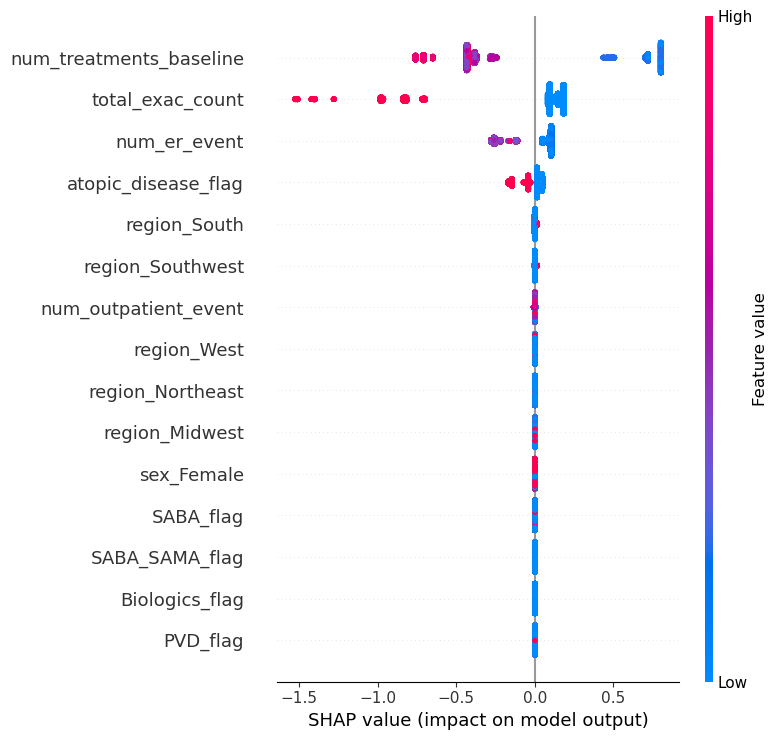

In [14]:
X_np = X_train.values if isinstance(X_train, pd.DataFrame) else X_train

proxy_tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=50, random_state=123)
proxy_tree.fit(X_np, tau_mean)

fi_df = (pd.DataFrame({"feature": feature_names,
                        "importance": proxy_tree.feature_importances_})
           .sort_values("importance", ascending=False))
print("\nTop 10 features driving HTE:")
print(fi_df.head(10).reset_index(drop=True).to_string(index=False))

explainer   = shap.TreeExplainer(proxy_tree)
shap_values = explainer.shap_values(X_np)
shap.summary_plot(shap_values, X_np, feature_names=feature_names, max_display=15,)